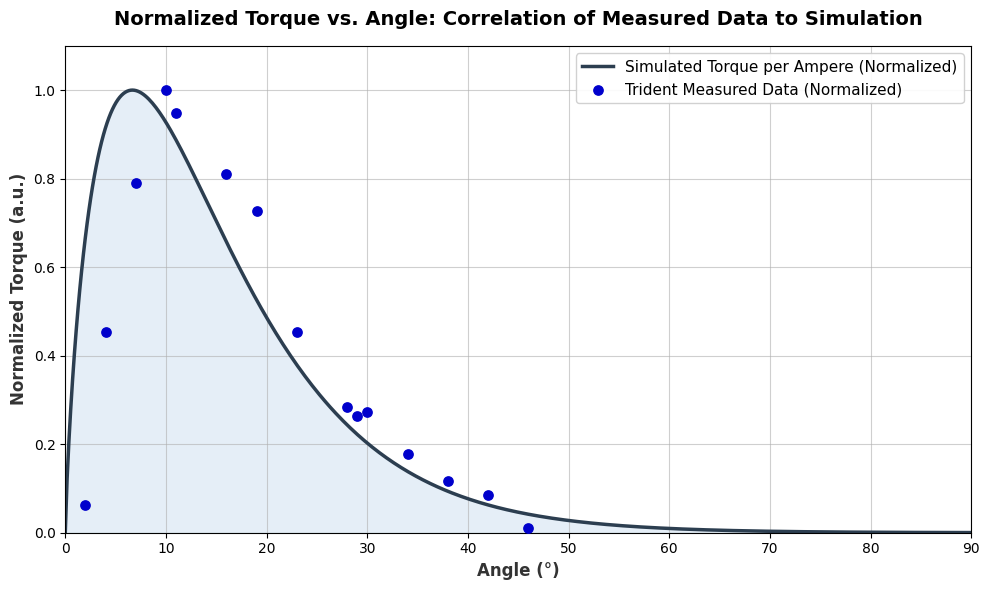

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extracted data points for the "Trident" scatter plot
angles_trident = np.array([2, 4, 7, 10, 11, 16, 19, 23, 28, 29, 30, 34, 38, 42, 46])
torque_trident = np.array([6, 43, 75, 95, 90, 77, 69, 43, 27, 25, 26, 17, 11, 8, 1])

# 2. Generate continuous data for the "Magnet Torque per Ampere" curve
# Using a function that closely mimics the visual shape of your second graph: y = A * x^b * e^(-cx)
angles_curve = np.linspace(0, 90, 500)
# This specific function peaks around 6.6 degrees and decays smoothly, matching your source image
torque_curve = 19 * (angles_curve**0.8) * np.exp(-0.12 * angles_curve)

# 3. Normalize both datasets to their maximum values (scale from 0 to 1)
# This solves the issue of the unknown current and different units (Nmm vs mNm/A)
norm_torque_trident = torque_trident / np.max(torque_trident)
norm_torque_curve = torque_curve / np.max(torque_curve)

# 4. Create the plot
plt.figure(figsize=(10, 6))

# Plot the continuous curve (matching the aesthetic of the second image)
plt.plot(angles_curve, norm_torque_curve, color='#2c3e50', linewidth=2.5, 
         label='Simulated Torque per Ampere (Normalized)')
plt.fill_between(angles_curve, norm_torque_curve, color='#dae8f5', alpha=0.7)

# Plot the experimental scatter points (matching the first image)
plt.scatter(angles_trident, norm_torque_trident, color='#0000cc', marker='o', 
            s=45, zorder=5, label='Trident Measured Data (Normalized)')

# 5. Formatting for the report
plt.title('Normalized Torque vs. Angle: Correlation of Measured Data to Simulation', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Angle (°)', fontsize=12, fontweight='bold', color='#333333')
plt.ylabel('Normalized Torque (a.u.)', fontsize=12, fontweight='bold', color='#333333')

# Set axis limits based on the original graphs
plt.xlim(0, 90)
plt.ylim(0, 1.1) # Adding 10% headroom above the peak

# Add grid and legend
plt.grid(True, linestyle='-', alpha=0.6)
plt.legend(fontsize=11, loc='upper right', framealpha=0.9)

# Clean up layout
plt.tight_layout()
plt.savefig('Diagrams and Images/torque_model.png', dpi=300)  # Save the plot for inclusion in the report

#
plt.show()